# Integrative Protocol for Protein–Protein Interaction and Gene Expression Analysis

This notebook builds condition-specific active PPI networks by integrating a STRING-derived reference interaction network with expression-supported active genes. 
---

## Section 1 — Setup: Imports and User Parameters

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import gzip
import shutil
import random

# ── Third-party ───────────────────────────────────────────────────────────────
import requests
import numpy as np
import pandas as pd
import networkx as nx
import community as community_louvain          # python-louvain
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from pathlib import Path
from collections import defaultdict 
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import (normalized_mutual_info_score,
                              adjusted_rand_score)

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# ── User-defined parameters ───────────────────────────────────────────────────
TAXID          = "83332"       # M. tuberculosis H37Rv taxonomy ID
STRING_VERSION = "v12.0"       # STRING database version
MIN_SCORE      = 700           # High-confidence interaction threshold (≥700)
RANDOM_SEED    = 42            # Reproducibility for layouts/permutation/Louvain

# Expression files (BED-like, tab-separated, GTF+count+TPM format)
LOG_EXPR_FILE    = "Mtbgtf_SRR18455932_exponential.bed"
STRESS_EXPR_FILE = "Mtbgtf_SRR18455925_starvation.bed"

# Derived file names
RAW_GZ  = f"{TAXID}.protein.links.{STRING_VERSION}.txt.gz"
RAW_TXT = f"{TAXID}.protein.links.{STRING_VERSION}.txt"

OUTDIR = Path("outputs")
OUTDIR.mkdir(exist_ok=True)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Organism  : M. tuberculosis H37Rv (TAXID {TAXID})")
print(f"STRING    : {STRING_VERSION}, min score {MIN_SCORE}")
print(f"Random seed: {RANDOM_SEED}")
print(f"Log file  : {LOG_EXPR_FILE}")
print(f"Stress file: {STRESS_EXPR_FILE}")
print(f"Output dir: {OUTDIR}/")

Organism  : M. tuberculosis H37Rv (TAXID 83332)
STRING    : v12.0, min score 700
Random seed: 42
Log file  : Mtbgtf_SRR18455932_exponential.bed
Stress file: Mtbgtf_SRR18455925_starvation.bed
Output dir: outputs/


## Section 2 — Download and Prepare the STRING Interaction Network

The STRING bulk file is downloaded once and cached locally.  
Each row contains two protein identifiers and a combined confidence score.

In [3]:
FILE_URL = (
    f"https://stringdb-downloads.org/download/"
    f"protein.links.{STRING_VERSION}/{RAW_GZ}"
)

# Download only if not already present
if not os.path.exists(RAW_GZ):
    print(f"Downloading {RAW_GZ} ...")
    with requests.get(FILE_URL, stream=True, timeout=300) as r:
        r.raise_for_status()
        with open(RAW_GZ, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
    print("Download complete.")
else:
    print(f"File already exists locally: {RAW_GZ}")

# Decompress only if not already done
if not os.path.exists(RAW_TXT):
    print("Decompressing ...")
    with gzip.open(RAW_GZ, "rb") as f_in, open(RAW_TXT, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
    print("Decompression complete.")
else:
    print(f"Decompressed file already exists: {RAW_TXT}")

Download complete.
Decompressing ...
Decompression complete.


In [4]:
# ── Load, filter, and clean the interaction table ────────────────────────────
ppi_raw = pd.read_csv(RAW_TXT, sep=r"\s+", header=0)  # header=0: use column-name row as header

# Coerce score to numeric; drop rows with invalid scores
ppi_raw["combined_score"] = pd.to_numeric(ppi_raw["combined_score"], errors="coerce")
ppi_raw = ppi_raw.dropna(subset=["combined_score"])

# Apply confidence threshold
ppi_raw = ppi_raw[ppi_raw["combined_score"] >= MIN_SCORE].copy()
print(f"High-confidence STRING rows retained: {len(ppi_raw):,}")

# Strip species prefix from STRING protein identifiers (e.g. "83332.Rv0001" → "Rv0001")
prefix = f"{TAXID}."
ppi = ppi_raw[["protein1", "protein2", "combined_score"]].copy()
ppi["geneA"] = ppi["protein1"].astype(str).str.replace(prefix, "", regex=False)
ppi["geneB"] = ppi["protein2"].astype(str).str.replace(prefix, "", regex=False)
ppi = ppi[["geneA", "geneB", "combined_score"]].dropna().copy()

# STRING bulk files can contain reciprocal entries (A-B and B-A). For an undirected
# PPI network, canonicalize each pair and retain the maximum confidence score.
pairs = np.sort(ppi[["geneA", "geneB"]].to_numpy(dtype=str), axis=1)
ppi["geneA"] = pairs[:, 0]
ppi["geneB"] = pairs[:, 1]
ppi = ppi[ppi["geneA"] != ppi["geneB"]].copy()  # remove self-loops, if any
ppi = (ppi.groupby(["geneA", "geneB"], as_index=False)["combined_score"]
          .max()
          .reset_index(drop=True))

ppi.to_csv(OUTDIR / "cleaned_STRING_high_confidence_ppi.tsv", sep="\t", index=False)

print(f"Unique undirected gene–gene interactions: {len(ppi):,}")
print(f"Saved cleaned PPI table: {OUTDIR / 'cleaned_STRING_high_confidence_ppi.tsv'}")
ppi.head()

High-confidence STRING rows retained: 60,058
Unique undirected gene–gene interactions: 30,029
Saved cleaned PPI table: outputs\cleaned_STRING_high_confidence_ppi.tsv


,geneA,geneB,combined_score
0,Rv0001,Rv0002,998
1,Rv0001,Rv0003,958
2,Rv0001,Rv0005,841
3,Rv0001,Rv0006,820
4,Rv0001,Rv0058,959


In [5]:
# ── Build static (reference) PPI network ─────────────────────────────────────
# The STRING combined_score is retained as an edge attribute. It is used later
# for weighted Louvain community detection and PageRank.
G_static = nx.from_pandas_edgelist(
    ppi,
    source="geneA",
    target="geneB",
    edge_attr="combined_score",
    create_using=nx.Graph()
)

print(f"Static network — nodes: {G_static.number_of_nodes():,}  |  "
      f"edges: {G_static.number_of_edges():,}")

Static network — nodes: 3,789  |  edges: 30,029


## Section 3 — Load Gene Expression Data

The BED-like files contain genomic coordinates, feature annotations, raw read counts, and a final normalized expression column. In this notebook the final column is handled as `expr`. If this column is true TPM, the total across genes should be close to 1,000,000; otherwise, describe it more cautiously as a normalized expression value.

Only **gene-level** rows are retained.

In [6]:
def load_expression(path: str) -> pd.DataFrame:
    """
    Parse a GTF+expression BED-like file and return a two-column DataFrame:
    gene (str) | expr (float).

    Expected columns (0-indexed):
      3  = gene identifier
      7  = feature type  ('gene', 'exon', …)
      -1 = normalized expression value used for activity filtering
    """
    df = pd.read_csv(path, sep="\t", header=None, low_memory=False)

    if df.shape[1] < 12:
        raise ValueError(f"{path}: expected ≥12 columns, found {df.shape[1]}")

    df = df.rename(columns={3: "gene", 7: "feature", df.shape[1] - 1: "expr"})
    df = df[df["feature"] == "gene"].copy()
    df["gene"] = df["gene"].astype(str).str.strip()
    df["expr"] = pd.to_numeric(df["expr"], errors="coerce")
    df = df.dropna(subset=["gene", "expr"]).reset_index(drop=True)
    return df[["gene", "expr"]]


expr_log    = load_expression(LOG_EXPR_FILE)
expr_stress = load_expression(STRESS_EXPR_FILE)

for label, df in [("Log (exponential)", expr_log), ("Stress (starvation)", expr_stress)]:
    expr_sum = df["expr"].sum()
    expr_min = df["expr"].min()
    expr_max = df["expr"].max()
    print(f"{label}: {len(df):,} genes  |  expression range: {expr_min:.3f} – {expr_max:.3f}  |  sum: {expr_sum:,.3f}")
    if expr_max > 1_000_000 or not (900_000 <= expr_sum <= 1_100_000):
        print("  NOTE: The final column does not behave like standard TPM. In the chapter, call it a normalized expression value unless TPM normalization is verified.")


Log (exponential): 4,008 genes  |  expression range: 0.000 – 810825.768  |  sum: 3,004,996.107
  NOTE: The final column does not behave like standard TPM. In the chapter, call it a normalized expression value unless TPM normalization is verified.
Stress (starvation): 4,008 genes  |  expression range: 0.000 – 2866027.727  |  sum: 5,369,923.424
  NOTE: The final column does not behave like standard TPM. In the chapter, call it a normalized expression value unless TPM normalization is verified.


## Section 4 — Median-Based Activity Filtering

Genes with normalized expression values **at or above** the per-condition median are classified as *active*. This provides a simple condition-specific activity definition without requiring differential-expression testing. These active genes should not be described as DEGs unless a separate statistical differential-expression analysis is performed.

In [7]:
median_log    = expr_log["expr"].median()
median_stress = expr_stress["expr"].median()

active_log    = set(expr_log.loc[expr_log["expr"]    >= median_log,    "gene"])
active_stress = set(expr_stress.loc[expr_stress["expr"] >= median_stress, "gene"])

print(f"Log    — median expression: {median_log:.3f}  |  active genes: {len(active_log):,}")
print(f"Stress — median expression: {median_stress:.3f}  |  active genes: {len(active_stress):,}")
print(f"\nGenes active in both conditions : {len(active_log & active_stress):,}")
print(f"Log-only active genes           : {len(active_log - active_stress):,}")
print(f"Stress-only active genes        : {len(active_stress - active_log):,}")


Log    — median expression: 161.026  |  active genes: 2,004
Stress — median expression: 9.906  |  active genes: 2,004

Genes active in both conditions : 1,476
Log-only active genes           : 528
Stress-only active genes        : 528


## Section 5 — Construct Condition-Specific PPI Networks

Active-gene sets are overlaid onto the static network by inducing subgraphs.  
Only edges where *both* endpoints are active in that condition are retained.

In [8]:
G_log    = G_static.subgraph(active_log).copy()
G_stress = G_static.subgraph(active_stress).copy()

for label, G in [("Log", G_log), ("Stress", G_stress)]:
    print(f"{label} network — nodes: {G.number_of_nodes():,}  |  "
          f"edges: {G.number_of_edges():,}")

Log network — nodes: 1,893  |  edges: 13,088
Stress network — nodes: 1,847  |  edges: 10,847


## Section 6 — Centrality Analysis

Five complementary metrics are computed for each condition-specific network:

| Metric | What it captures |
|---|---|
| **Degree** | Local connectivity (number of direct neighbours) |
| **Betweenness** | Bottleneck influence (fraction of shortest paths through a node) |
| **Closeness** | Global reach (inverse average distance to all other nodes) |
| **Eigenvector** | Influence weighted by neighbour importance |
| **PageRank** | Iterative influence propagation (analogous to Google's algorithm) |

In [9]:
def compute_centrality(G: nx.Graph, label: str) -> pd.DataFrame:
    """Return a DataFrame of centrality metrics for all nodes in G."""
    print(f"Computing centrality for {label} network ({G.number_of_nodes():,} nodes) …")
    
    if G.number_of_nodes() == 0:
        return pd.DataFrame(columns=["gene", "degree", "weighted_degree", "betweenness", "closeness", "eigenvector", "pagerank"])

    # Degree is kept unweighted because it is biologically interpretable as the
    # number of direct partners. Weighted degree summarizes cumulative STRING confidence.
    weighted_degree = dict(G.degree(weight="combined_score"))

    # STRING combined_score is a confidence score, not a distance. Therefore,
    # betweenness/closeness are computed on the unweighted topology.
    betweenness = nx.betweenness_centrality(G, normalized=True)
    closeness   = nx.closeness_centrality(G)

    try:
        eigenvector = nx.eigenvector_centrality(G, max_iter=1000, weight="combined_score")
    except nx.PowerIterationFailedConvergence:
        print("  Warning: eigenvector centrality did not converge; using unweighted fallback.")
        eigenvector = nx.eigenvector_centrality(G, max_iter=2000)

    pagerank = nx.pagerank(G, weight="combined_score")

    df = pd.DataFrame({
        "gene":            list(G.nodes()),
        "degree":          [G.degree(n) for n in G.nodes()],
        "weighted_degree": [weighted_degree[n] for n in G.nodes()],
        "betweenness":     [betweenness[n] for n in G.nodes()],
        "closeness":       [closeness[n] for n in G.nodes()],
        "eigenvector":     [eigenvector[n] for n in G.nodes()],
        "pagerank":        [pagerank[n] for n in G.nodes()],
    })
    print(f"  Done.\n")
    return df


cent_log    = compute_centrality(G_log,    "Log")
cent_stress = compute_centrality(G_stress, "Stress")

cent_log.to_csv(OUTDIR / "centrality_log.tsv", sep="\t", index=False)
cent_stress.to_csv(OUTDIR / "centrality_stress.tsv", sep="\t", index=False)

print("Top 10 genes by degree — Log phase:")
print(cent_log.sort_values("degree", ascending=False)
              .head(10)[["gene", "degree", "weighted_degree", "betweenness", "pagerank"]]
              .to_string(index=False))

Computing centrality for Log network (1,893 nodes) …
  Done.

Computing centrality for Stress network (1,847 nodes) …
  Done.

Top 10 genes by degree — Log phase:
   gene  degree  weighted_degree  betweenness  pagerank
 Rv0701     135           123570     0.020009  0.002671
 Rv0682     133           122900     0.012296  0.002579
 Rv0721     133           121194     0.010207  0.002491
 Rv0704     130           119212     0.005358  0.002374
Rv3443c     129           118065     0.010558  0.002394
 Rv0702     128           118528     0.005924  0.002352
 Rv0667     124           111579     0.022333  0.002713
 Rv0683     122           112358     0.006136  0.002240
Rv3459c     121           112547     0.004310  0.002213
Rv2890c     121           111721     0.010420  0.002293


## Section 7 — Union-Based Centrality Core

A gene is included in the *centrality core* if it scores **at or above the median**  
in **any** of the five metrics.  The union captures robust hubs without favouring  
a single measure.

In [10]:
def centrality_core(df: pd.DataFrame) -> set:
    """Return the union of above-median genes across centrality metrics."""
    metrics = ["degree", "weighted_degree", "betweenness", "closeness", "eigenvector", "pagerank"]
    return set().union(*[
        set(df.loc[df[col] >= df[col].median(), "gene"])
        for col in metrics
    ])


core_log    = centrality_core(cent_log)
core_stress = centrality_core(cent_stress)

shared_core      = core_log & core_stress       # conserved hubs
log_only_core    = core_log - core_stress       # log-specific core genes
stress_only_core = core_stress - core_log       # stress-specific core genes

print(f"Log centrality core      : {len(core_log):,} genes")
print(f"Stress centrality core   : {len(core_stress):,} genes")
print(f"Shared core              : {len(shared_core):,}")
print(f"Log-only core            : {len(log_only_core):,}")
print(f"Stress-only core         : {len(stress_only_core):,}")

Log centrality core      : 1,367 genes
Stress centrality core   : 1,364 genes
Shared core              : 940
Log-only core            : 427
Stress-only core         : 424


In [11]:
# Per-metric correlation (log vs. stress) — how conserved is the centrality hierarchy?
common = pd.merge(cent_log, cent_stress, on="gene", suffixes=("_log", "_stress"))

print("Per-metric Spearman correlation (log vs. stress):")
for m in ["degree", "weighted_degree", "betweenness", "closeness", "eigenvector", "pagerank"]:
    r, _ = spearmanr(common[f"{m}_log"], common[f"{m}_stress"])
    print(f"  {m:16s}: ρ = {r:.3f}")

Per-metric Spearman correlation (log vs. stress):
  degree          : ρ = 0.953
  weighted_degree : ρ = 0.954
  betweenness     : ρ = 0.852
  closeness       : ρ = 0.956
  eigenvector     : ρ = 0.953
  pagerank        : ρ = 0.895


## Section 8 — Community Detection (Louvain Algorithm)

The Louvain algorithm maximises network modularity to partition genes into  
functionally coherent communities.  Resolution = 1.0 (default).

In [12]:
def detect_communities(G: nx.Graph, label: str, resolution: float = 1.0) -> pd.DataFrame:
    """
    Run the Louvain algorithm and return a DataFrame mapping gene → community ID.
    Community IDs are re-indexed by size (0 = largest).
    """
    partition = community_louvain.best_partition(
        G,
        resolution=resolution,
        random_state=RANDOM_SEED,
        weight="combined_score"
    )
    n_comms = len(set(partition.values()))
    print(f"{label}: {n_comms} communities detected")

    df = pd.DataFrame({
        "gene":      list(partition.keys()),
        "community": list(partition.values()),
    })

    # Re-label communities by descending size so community 0 is always the largest
    size_order = (df["community"].value_counts()
                                 .reset_index()
                                 .reset_index()
                                 .rename(columns={"index": "new_id", "community": "old_id"}))
    remap = dict(zip(size_order["old_id"], size_order["new_id"]))
    df["community"] = df["community"].map(remap)

    print(f"  Largest community: {df['community'].value_counts().iloc[0]:,} genes")
    return df


comm_log    = detect_communities(G_log,    "Log")
comm_stress = detect_communities(G_stress, "Stress")

comm_log.to_csv(OUTDIR    / "communities_log.tsv",    sep="\t", index=False)
comm_stress.to_csv(OUTDIR / "communities_stress.tsv", sep="\t", index=False)
print(f"\nSaved community files to {OUTDIR}/")

Log: 131 communities detected
  Largest community: 268 genes
Stress: 163 communities detected
  Largest community: 261 genes

Saved community files to outputs/


In [13]:
# Community structure comparison using shared genes
common_genes  = list(set(comm_log["gene"]) & set(comm_stress["gene"]))
labels_log    = comm_log.set_index("gene").loc[common_genes, "community"].values
labels_stress = comm_stress.set_index("gene").loc[common_genes, "community"].values

nmi = normalized_mutual_info_score(labels_log, labels_stress)
ari = adjusted_rand_score(labels_log, labels_stress)

print(f"Genes evaluated (shared): {len(common_genes):,}")
print(f"NMI  (0 = independent, 1 = identical): {nmi:.4f}")
print(f"ARI  (0 = random,      1 = identical): {ari:.4f}")
print("\nInterpretation: NMI/ARI quantify how similar the community assignments are between conditions. Moderate values indicate partial conservation with measurable reorganization.")

Genes evaluated (shared): 1,378
NMI  (0 = independent, 1 = identical): 0.6347
ARI  (0 = random,      1 = identical): 0.4135

Interpretation: NMI/ARI quantify how similar the community assignments are between conditions. Moderate values indicate partial conservation with measurable reorganization.


## Section 9 — Chapter Protocol Figures and Visualisations

This section generates clean figure for the book chapter protocol. The figures are designed to show how a static PPI/functional-association network is converted into condition-specific active networks after integration with gene expression data.




In [14]:
# ── Plot style and helper functions ──────────────────────────────────────────
import math
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle, FancyArrowPatch, FancyBboxPatch

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 600,
})

FIGDIR = OUTDIR / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, filename: str):
    """Save a figure as both PNG and PDF for manuscript/chapter use."""
    png = FIGDIR / f"{filename}.png"
    pdf = FIGDIR / f"{filename}.pdf"
    fig.savefig(png, dpi=600, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    print(f"Saved: {png}")
    print(f"Saved: {pdf}")

def canonical_edge_set(G: nx.Graph) -> set:
    """Return undirected edges in canonical sorted tuple format."""
    return {tuple(sorted(e)) for e in G.edges()}

def top_shift_labels(df: pd.DataFrame, metric: str, n: int = 6) -> pd.DataFrame:
    """Return genes with the largest absolute centrality shift for labelling."""
    d = df.copy()
    d["abs_shift"] = (d[f"{metric}_stress"] - d[f"{metric}_log"]).abs()
    return d.nlargest(n, "abs_shift")


## Section 10 — User-Guided PPI Subnetwork Visualisation

This section is the **interactive step** of the protocol.  
After examining the centrality ranks (Section 6–7) and community assignments (Section 8),
you choose the genes that are biologically meaningful to you — based on prior knowledge,
your experimental context, or the patterns you see in the outputs above — and supply them
through a simple CSV file.  The notebook then plots their condition-specific PPI subnetwork
with gene names as labels.

### How to use this section

1. Open **`user_genes_of_interest.csv`** (an example file is provided alongside this notebook).
2. Replace the example entries with your own genes of interest.  
   Accepted formats: gene name (`gyrA`) *or* locus tag (`Rv0006`).
3. The optional **`group`** column lets you assign each gene to a functional category  
   (e.g. `"Stress_response"`, `"Cell_division"`).  If present:
   - **Node fill colour** = functional group you defined.
   - **Node border colour** = condition-activity state (log / stress / common active).  
   If you omit the `group` column, nodes are filled by condition-activity state only.
4. Re-run this cell.  The plot and a node-metadata CSV are saved automatically.

### Input file format (`user_genes_of_interest.csv`)

| Column | Required | Description |
|---|---|---|
| `gene_name` | ✓ | Gene name *or* locus tag (e.g. `gyrA` or `Rv0006`) |
| `group` | optional | Free-text functional category for colour-coding |

> **Tip:** If any gene is reported as "not found", check its spelling against  
> `locus_id_gene_name_no_blank.csv`; try the locus tag (e.g. `Rv0667`) if the  
> gene name is not recognised.


Name mapping loaded : 4,008 locus-to-name entries

Input file         : user_genes_of_interest.csv
Genes listed       : 20
Group column found : True
  [Carbon_Metabolism] icl1
  [Cell_Division] ftsZ, rodA
  [Chaperone] dnaK, groES
  [DNA_Repair] recA, recF
  [DNA_Replication] dnaA, dnaN, gyrA, gyrB
  [Lipid_Metabolism] inhA
  [Oxidative_Defense] katG, sodA
  [Signal_Transduction] pknB, pknA
  [Stress_Response] sigH
  [Transcription] rpoB, rpoC, sigA

Genes matched to network : 20 / 20
Subnetwork     : 24 nodes | 97 edges
Connectors     : 5 added | 1 isolate(s) removed


C:\Users\bshar\AppData\Local\Temp\ipykernel_36500\1578652112.py:216: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Times New Roman.
  fig.tight_layout()
C:\Users\bshar\AppData\Local\Temp\ipykernel_36500\1206885414.py:24: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Times New Roman.
  fig.savefig(png, dpi=600, bbox_inches="tight")
C:\Users\bshar\AppData\Local\Temp\ipykernel_36500\1206885414.py:25: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Times New Roman.
  fig.savefig(pdf, bbox_inches="tight")


Saved: outputs\figures\Fig_UserGuided_GeneOfInterest_Network.png
Saved: outputs\figures\Fig_UserGuided_GeneOfInterest_Network.pdf


C:\Users\bshar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)


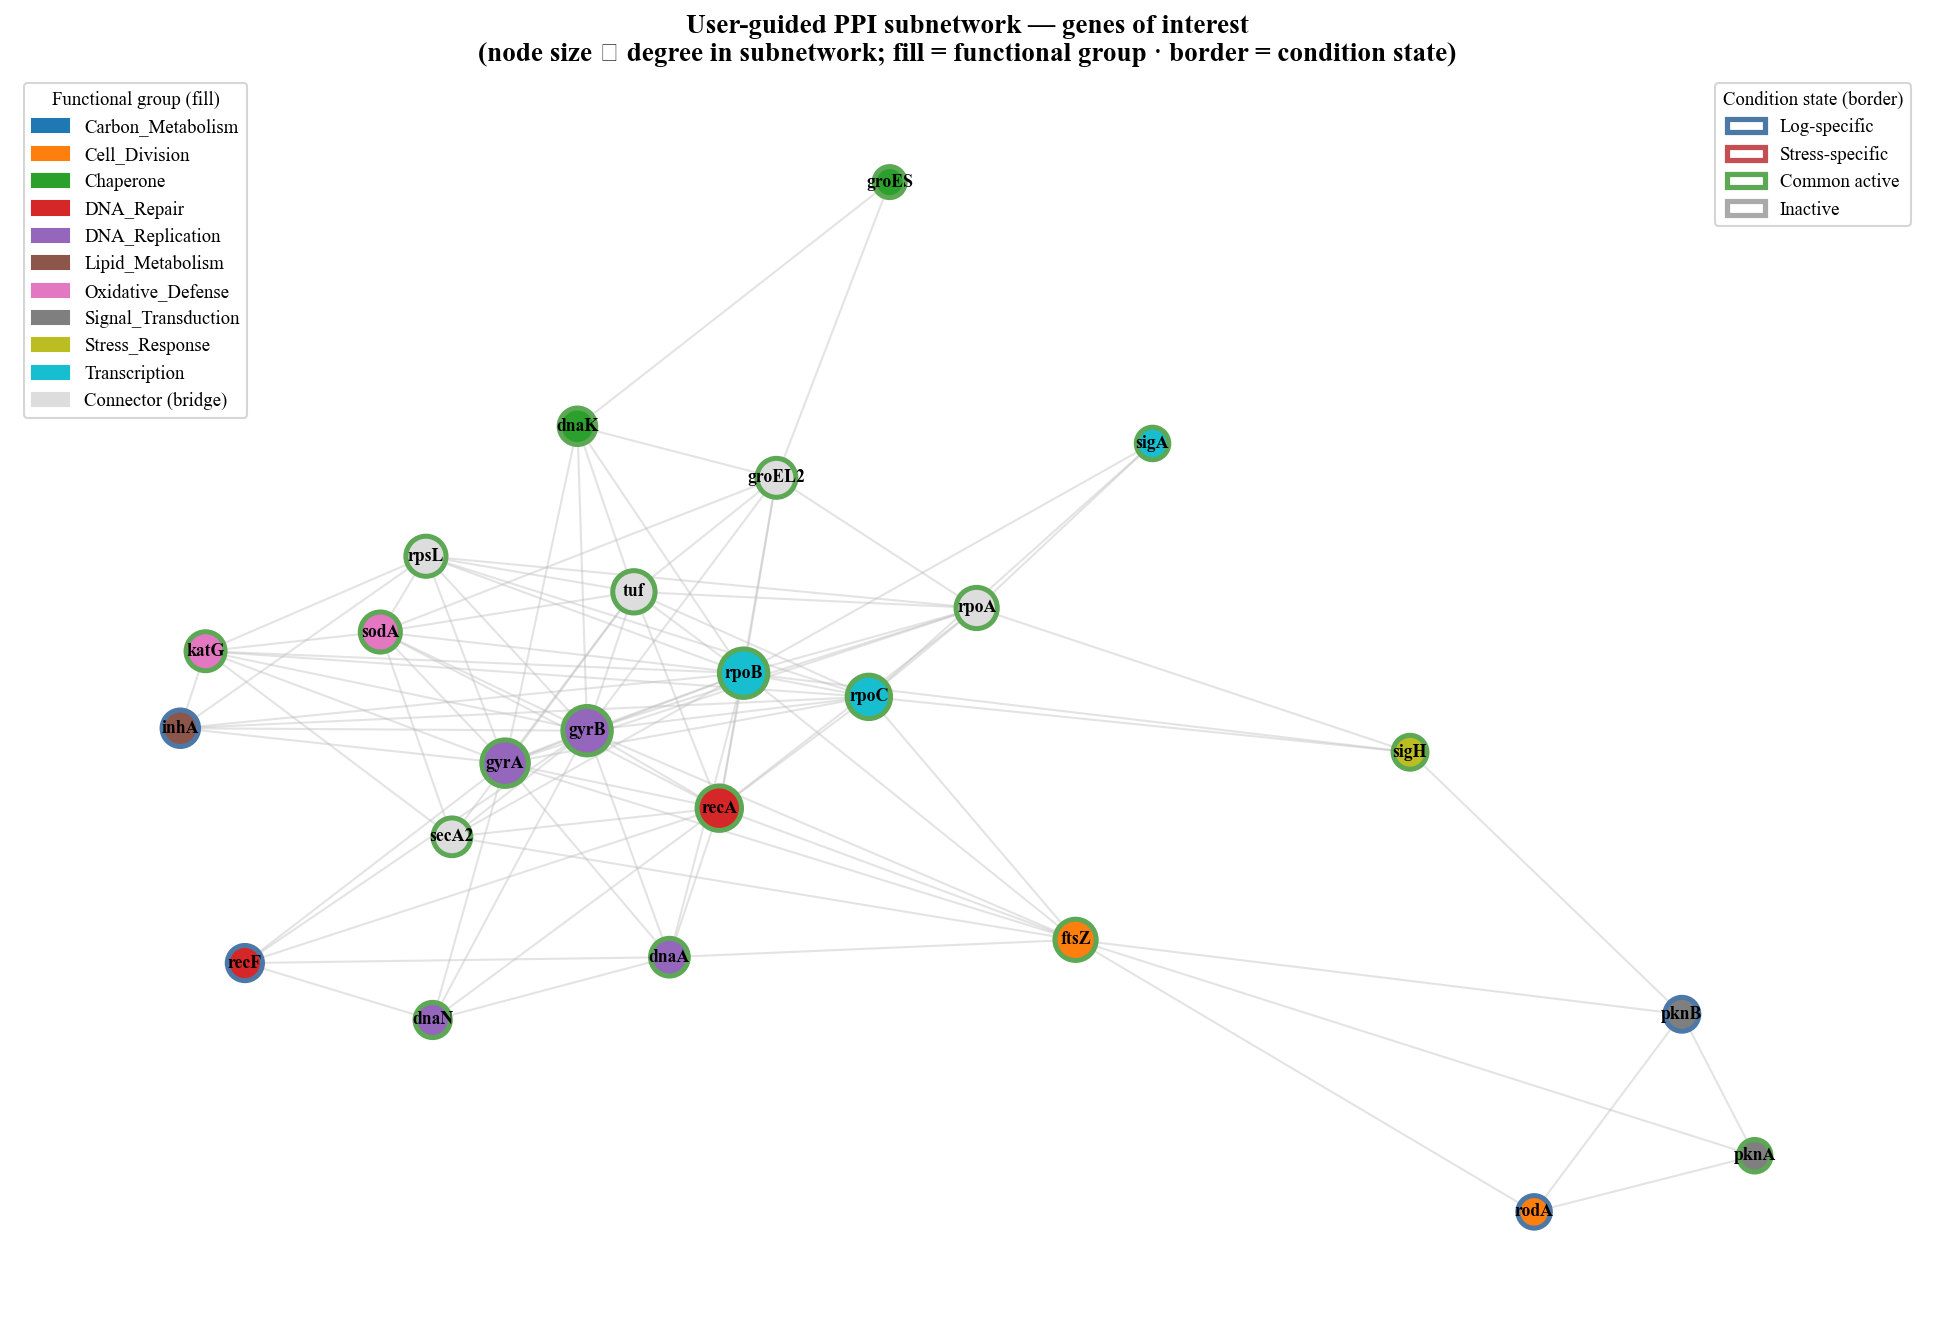


Node metadata saved → outputs\user_guided_subnetwork_nodes.csv
locus_id gene_name condition_state  degree_in_plot          user_group
  Rv0667      rpoB   Common active              17       Transcription
  Rv0005      gyrB   Common active              17     DNA_Replication
  Rv0006      gyrA   Common active              15     DNA_Replication
 Rv2737c      recA   Common active              13          DNA_Repair
  Rv0668      rpoC   Common active              12       Transcription
  Rv0685       tuf   Common active              11           Connector
 Rv2150c      ftsZ   Common active              10       Cell_Division
 Rv3457c      rpoA   Common active              10           Connector
  Rv3846      sodA   Common active               9   Oxidative_Defense
  Rv0682      rpsL   Common active               9           Connector
  Rv0440    groEL2   Common active               8           Connector
 Rv1908c      katG   Common active               8   Oxidative_Defense
  Rv1821     

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 10 — User-Guided PPI Subnetwork Visualisation
# ══════════════════════════════════════════════════════════════════════════════
#
# ▶  USER PARAMETER — update this path if your file has a different name
GENES_OF_INTEREST_FILE = "user_genes_of_interest.csv"
#
# ══════════════════════════════════════════════════════════════════════════════

# ── 1. Build bidirectional locus ↔ gene-name mapping ─────────────────────────
GENE_NAME_MAP_FILE = "locus_id_gene_name_no_blank.csv"

name_df  = pd.read_csv(GENE_NAME_MAP_FILE)
name_map = dict(zip(name_df["locus_id"], name_df["gene_name"]))  # locus → name

# Reverse map: gene_name → locus_id.
# Both gene names AND locus IDs are accepted in the input file.
name_to_locus: dict = {}
for locus, gname in name_map.items():
    name_to_locus[gname]  = locus   # gene name  → locus
    name_to_locus[locus]  = locus   # locus tag  → locus (pass-through)

print(f"Name mapping loaded : {len(name_map):,} locus-to-name entries")

# ── 2. Load user gene list ────────────────────────────────────────────────────
goi_df = pd.read_csv(GENES_OF_INTEREST_FILE)

if "gene_name" not in goi_df.columns:
    raise ValueError(
        "Input file must contain a 'gene_name' column. "
        "See the example file user_genes_of_interest.csv."
    )

has_group = "group" in goi_df.columns
print(f"\nInput file         : {GENES_OF_INTEREST_FILE}")
print(f"Genes listed       : {len(goi_df)}")
print(f"Group column found : {has_group}")
if has_group:
    for g, sub in goi_df.groupby("group", sort=True):
        print(f"  [{g}] {', '.join(sub['gene_name'].tolist())}")

# ── 3. Map to locus IDs; warn on mismatches ───────────────────────────────────
goi_df = goi_df.copy()
goi_df["locus_id"] = goi_df["gene_name"].map(name_to_locus)

not_in_map = goi_df[goi_df["locus_id"].isna()]["gene_name"].tolist()
if not_in_map:
    print(f"\n⚠  Not found in name map (skipped) — check spelling or use locus tag:")
    print("   " + ", ".join(not_in_map))

goi_df = goi_df.dropna(subset=["locus_id"]).copy()

# ── 4. Filter to genes present in the static STRING network ───────────────────
in_net = goi_df[goi_df["locus_id"].isin(G_static.nodes())].copy()
not_in_net = goi_df[~goi_df["locus_id"].isin(G_static.nodes())]["gene_name"].tolist()
if not_in_net:
    print(f"\n⚠  Not in static PPI network (skipped — below STRING score threshold?):")
    print("   " + ", ".join(not_in_net))

print(f"\nGenes matched to network : {len(in_net)} / {len(goi_df)}")

if len(in_net) < 2:
    raise ValueError(
        "Fewer than 2 genes matched the PPI network.\n"
        "Please update 'user_genes_of_interest.csv' with valid gene names or locus tags."
    )

selected_loci = set(in_net["locus_id"])

# ── 5. Build subnetwork + optional structural connectors ──────────────────────
# Connector genes: non-selected nodes neighbouring ≥2 selected genes.
# They reveal structural bridges and are shown in a neutral colour.
connector_candidates = [
    (n, len(set(G_static.neighbors(n)) & selected_loci))
    for n in set(G_static.nodes()) - selected_loci
]
connector_candidates = sorted(
    [(n, k) for n, k in connector_candidates if k >= 2],
    key=lambda x: x[1], reverse=True
)
connectors = {n for n, _ in connector_candidates[:5]}  # at most 5 connectors

H = G_static.subgraph(selected_loci | connectors).copy()

isolates = list(nx.isolates(H))
H.remove_nodes_from(isolates)

print(f"Subnetwork     : {H.number_of_nodes()} nodes | {H.number_of_edges()} edges")
print(f"Connectors     : {len(connectors)} added | {len(isolates)} isolate(s) removed")

# ── 6. Condition-activity state (used for border colour) ──────────────────────
nodes_log_set    = set(G_log.nodes())
nodes_stress_set = set(G_stress.nodes())

COND_COLORS = {
    "Log-specific":    "#4C78A8",   # steel blue
    "Stress-specific": "#C44E52",   # muted red
    "Common active":   "#5DA854",   # mid green
    "Inactive":        "#AAAAAA",   # grey (in static but not active in either)
}

def cond_state(locus: str) -> str:
    in_l = locus in nodes_log_set
    in_s = locus in nodes_stress_set
    if in_l and in_s: return "Common active"
    if in_l:          return "Log-specific"
    if in_s:          return "Stress-specific"
    return "Inactive"

# ── 7. Relabel nodes with gene names ─────────────────────────────────────────
label_map     = {n: name_map.get(n, n) for n in H.nodes()}
label_map_inv = {v: k for k, v in label_map.items()}   # display name → locus
H_named       = nx.relabel_nodes(H, label_map)

deg_named = dict(H_named.degree())
max_deg   = max(deg_named.values(), default=1)

# ── 8. Fill-colour logic ──────────────────────────────────────────────────────
if has_group:
    groups_sorted = sorted(in_net["group"].unique())
    # Use tab10 for ≤10 groups, tab20 for up to 20; beyond that colours repeat.
    cmap = plt.cm.tab10 if len(groups_sorted) <= 10 else plt.cm.tab20
    group_fill = {g: cmap(i % 20) for i, g in enumerate(groups_sorted)}
    locus_to_grp = dict(zip(in_net["locus_id"], in_net["group"]))

    def fill_color(locus: str):
        return group_fill.get(locus_to_grp.get(locus), "#DDDDDD")  # #DDDDDD = connector
else:
    def fill_color(locus: str):
        return COND_COLORS[cond_state(locus)]

# ── 9. Plot ───────────────────────────────────────────────────────────────────
pos = nx.spring_layout(H_named, seed=RANDOM_SEED, k=1.0, iterations=400)
fig, ax = plt.subplots(figsize=(13, 9))

# Edges
nx.draw_networkx_edges(
    H_named, pos,
    edge_color="#BBBBBB", width=1.0, alpha=0.40, ax=ax
)

# Nodes
all_named = list(H_named.nodes())
all_loci  = [label_map_inv.get(n, n) for n in all_named]

node_fills  = [fill_color(locus) for locus in all_loci]
node_edges  = [COND_COLORS[cond_state(locus)] for locus in all_loci]
node_sizes  = [180 + 360 * (deg_named[n] / max_deg) for n in all_named]

nx.draw_networkx_nodes(
    H_named, pos,
    nodelist=all_named,
    node_color=node_fills,
    node_size=node_sizes,
    edgecolors=node_edges,
    linewidths=2.4,
    ax=ax
)

# Gene-name labels
nx.draw_networkx_labels(
    H_named, pos,
    labels={n: n for n in H_named.nodes()},
    font_size=8.5,
    font_family="Times New Roman",
    font_weight="bold",
    ax=ax
)

# ── 10. Legends ───────────────────────────────────────────────────────────────
if has_group:
    # Left legend: fill colour = user-defined functional group
    fill_handles = [
        mpatches.Patch(color=group_fill[g], label=g) for g in groups_sorted
    ]
    fill_handles.append(mpatches.Patch(color="#DDDDDD", label="Connector (bridge)"))
    leg1 = ax.legend(
        handles=fill_handles,
        loc="upper left", bbox_to_anchor=(0.0, 1.0),
        frameon=True, fontsize=9,
        title="Functional group (fill)", title_fontsize=9
    )
    ax.add_artist(leg1)

    # Right legend: border colour = condition-activity state
    cond_handles = [
        mpatches.Patch(facecolor="white", edgecolor=c, linewidth=2.5, label=s)
        for s, c in COND_COLORS.items()
    ]
    ax.legend(
        handles=cond_handles,
        loc="upper right", bbox_to_anchor=(1.0, 1.0),
        frameon=True, fontsize=9,
        title="Condition state (border)", title_fontsize=9
    )
else:
    cond_handles = [
        mpatches.Patch(color=c, label=s) for s, c in COND_COLORS.items()
    ]
    ax.legend(
        handles=cond_handles,
        loc="lower center", bbox_to_anchor=(0.5, -0.07),
        ncol=4, frameon=False, fontsize=10
    )

title_suffix = (
    "; fill = functional group · border = condition state"
    if has_group else ""
)
ax.set_title(
    f"User-guided PPI subnetwork — genes of interest\n"
    f"(node size ∝ degree in subnetwork{title_suffix})",
    fontsize=13, fontweight="bold"
)
ax.axis("off")
fig.tight_layout()
save_figure(fig, "Fig_UserGuided_GeneOfInterest_Network")
plt.show()

# ── 11. Save node metadata ────────────────────────────────────────────────────
node_meta_rows = []
for locus in H.nodes():
    row = {
        "locus_id":        locus,
        "gene_name":       label_map.get(locus, locus),
        "condition_state": cond_state(locus),
        "degree_in_plot":  H.degree(locus),
    }
    if has_group:
        row["user_group"] = locus_to_grp.get(locus, "Connector")
    node_meta_rows.append(row)

node_meta = (pd.DataFrame(node_meta_rows)
               .sort_values("degree_in_plot", ascending=False)
               .reset_index(drop=True))

node_meta.to_csv(OUTDIR / "user_guided_subnetwork_nodes.csv", index=False)
print(f"\nNode metadata saved → {OUTDIR / 'user_guided_subnetwork_nodes.csv'}")
print(node_meta.to_string(index=False))


## Section 11 — Results Summary

Run the cell below after executing all previous sections to print a consolidated
summary and list all generated output files.


In [16]:
print("=" * 64)
print("  RESULTS SUMMARY")
print("=" * 64)

print("\n[Static reference network (STRING)]")
print(f"  Nodes : {G_static.number_of_nodes():,}")
print(f"  Edges : {G_static.number_of_edges():,}")

print("\n[Condition-specific active networks]")
for label, G in [("Log", G_log), ("Stress", G_stress)]:
    print(f"  {label:6s} — nodes: {G.number_of_nodes():,}  "
          f"edges: {G.number_of_edges():,}")

print("\n[Condition-activity overlap]")
_nl = set(G_log.nodes()); _ns = set(G_stress.nodes())
print(f"  Common active genes  : {len(_nl & _ns):,}")
print(f"  Log-only active      : {len(_nl - _ns):,}")
print(f"  Stress-only active   : {len(_ns - _nl):,}")

print("\n[Centrality core sets (union-above-median, Sections 6-7)]")
print(f"  Log    core : {len(core_log):,} genes")
print(f"  Stress core : {len(core_stress):,} genes")
print(f"  Shared      : {len(shared_core):,}  |  "
      f"Log-only: {len(log_only_core):,}  |  "
      f"Stress-only: {len(stress_only_core):,}")

print("\n[Community detection — Louvain (Section 8)]")
print(f"  Log phase    : {comm_log['community'].nunique()} communities")
print(f"  Stress phase : {comm_stress['community'].nunique()} communities")

# User-guided subnetwork summary (Section 10)
if "H" in dir() and H is not None:
    print("\n[User-guided subnetwork (Section 10)]")
    print(f"  Nodes plotted : {H.number_of_nodes()}")
    print(f"  Edges plotted : {H.number_of_edges()}")
    _states = {
        s: sum(1 for n in H.nodes() if cond_state(n) == s)
        for s in ["Log-specific", "Stress-specific", "Common active", "Inactive"]
    }
    for s, cnt in _states.items():
        print(f"  {s:20s}: {cnt}")
    if "has_group" in dir() and has_group and "locus_to_grp" in dir():
        print(f"  User-defined groups : {len(groups_sorted)}")
        for g in groups_sorted:
            n_g = sum(1 for v in locus_to_grp.values() if v == g)
            print(f"    {g}: {n_g} gene(s)")

print("\n[Generated figures]")
for p in sorted(FIGDIR.glob("*.png")):
    print(f"  - {p.name}")

print("=" * 64)


  RESULTS SUMMARY

[Static reference network (STRING)]
  Nodes : 3,789
  Edges : 30,029

[Condition-specific active networks]
  Log    — nodes: 1,893  edges: 13,088
  Stress — nodes: 1,847  edges: 10,847

[Condition-activity overlap]
  Common active genes  : 1,378
  Log-only active      : 515
  Stress-only active   : 469

[Centrality core sets (union-above-median, Sections 6-7)]
  Log    core : 1,367 genes
  Stress core : 1,364 genes
  Shared      : 940  |  Log-only: 427  |  Stress-only: 424

[Community detection — Louvain (Section 8)]
  Log phase    : 131 communities
  Stress phase : 163 communities

[User-guided subnetwork (Section 10)]
  Nodes plotted : 24
  Edges plotted : 97
  Log-specific        : 4
  Stress-specific     : 0
  Common active       : 20
  Inactive            : 0
  User-defined groups : 10
    Carbon_Metabolism: 1 gene(s)
    Cell_Division: 2 gene(s)
    Chaperone: 2 gene(s)
    DNA_Repair: 2 gene(s)
    DNA_Replication: 4 gene(s)
    Lipid_Metabolism: 1 gene(s)
   